In [ ]:
import pandas as pd

# Load the raw file
df = pd.read_csv("gold_data.csv")

# Convert Date column to real datetime — dayfirst=True because format is DD/MM/YYYY
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort chronologically (oldest first) — critical for time series
df = df.sort_values('Date')

# Set Date as index, since statsmodels expects this structure
df.set_index('Date', inplace=True)

# We only need Price for this project — drop the rest for now
df = df[['Price']]

print(df.shape)
df.head()

(1804, 1)


,Price
Date,
2015-09-29,1127.1
2015-09-30,1115.5
2015-10-01,1114.0
2015-10-02,1136.7
2015-10-05,1137.7


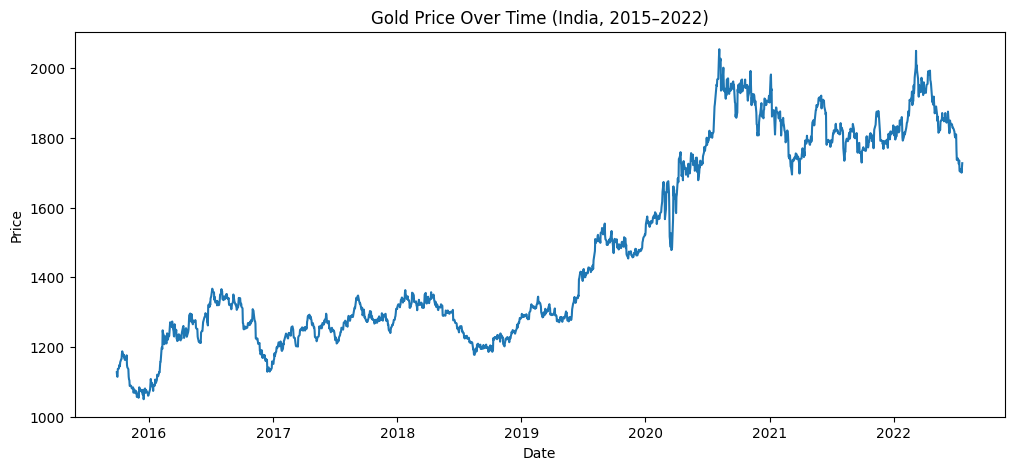

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Price'])
plt.title("Gold Price Over Time (India, 2015–2022)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Price'], model='additive', period=30)
decomposition.plot()
plt.show()